In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# 리뷰 데이터 기본 확인
print(pd.read_sql("""
SELECT
    COUNT(*) AS total_reviews,
    COUNT(DISTINCT order_id) AS reviewed_orders,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    MIN(review_score) AS min_review_score,
    MAX(review_score) AS max_review_score
FROM order_reviews;
""", conn))

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
   total_reviews  reviewed_orders  avg_review_score  min_review_score  \
0          99224            98673              4.09                 1   

   max_review_score  
0                 5  


   review_score  review_count  review_pct
0             1         11424       11.51
1             2          3151        3.18
2             3          8179        8.24
3             4         19142       19.29
4             5         57328       57.78


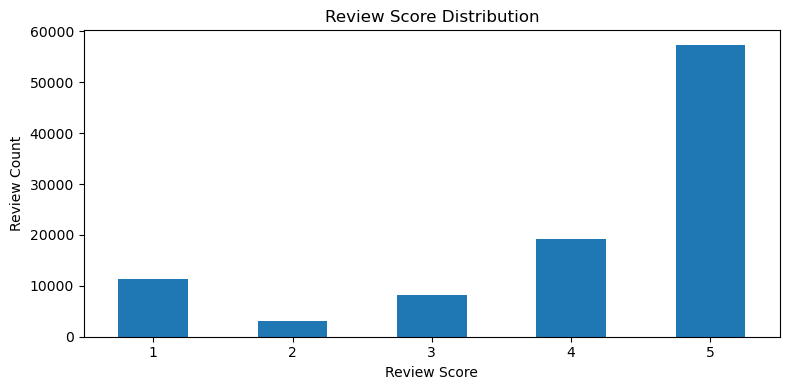

In [2]:
# 리뷰 점수 분포 확인
review_score_dist = pd.read_sql("""
SELECT
    review_score,
    COUNT(*) AS review_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM order_reviews), 2) AS review_pct
FROM order_reviews
GROUP BY review_score
ORDER BY review_score;
""", conn)

print(review_score_dist)

# 시각화
review_score_dist.plot(
    kind="bar",
    x="review_score",
    y="review_count",
    figsize=(8, 4),
    legend=False
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Review Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

  review_month  review_count  avg_review_score
0      2016-10           151              4.16
1      2016-11           110              3.22
2      2016-12            50              2.36
3      2017-01           198              4.40
4      2017-02          1368              4.29


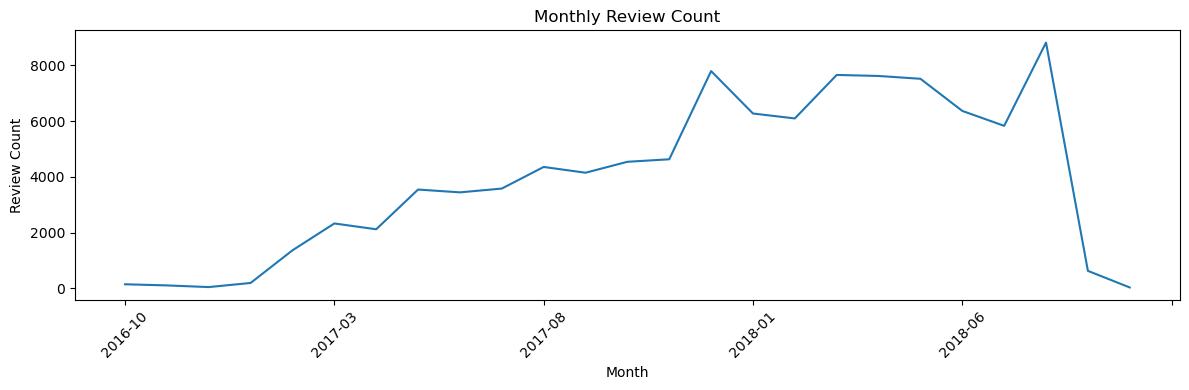

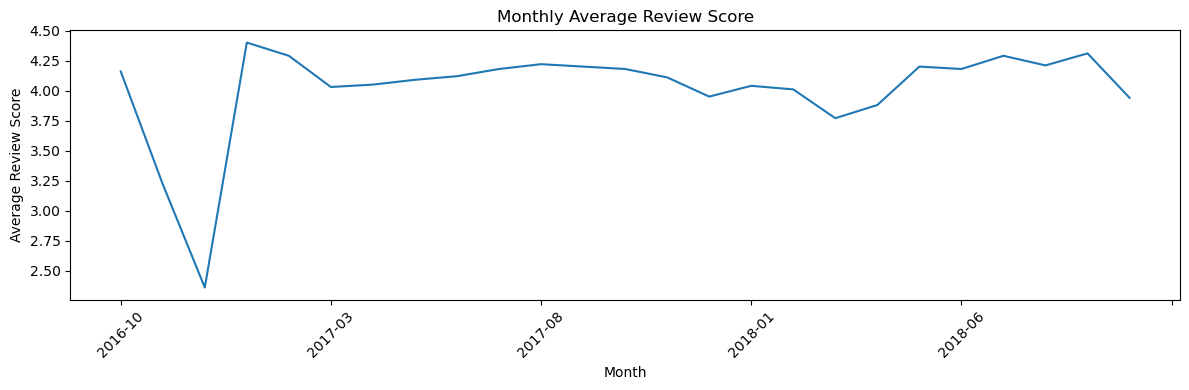

In [3]:
# 월별 리뷰 수 / 평균 리뷰 점수 추이
monthly_review = pd.read_sql("""
SELECT
    strftime('%Y-%m', review_answer_timestamp) AS review_month,
    COUNT(*) AS review_count,
    ROUND(AVG(review_score), 2) AS avg_review_score
FROM order_reviews
WHERE review_answer_timestamp IS NOT NULL
GROUP BY review_month
ORDER BY review_month;
""", conn)

print(monthly_review.head())

# 월별 리뷰 수 추이
monthly_review.plot(
    x="review_month",
    y="review_count",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Review Count")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 월별 평균 리뷰 점수 추이
monthly_review.plot(
    x="review_month",
    y="avg_review_score",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Average Review Score")
plt.xlabel("Month")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# 리뷰 수가 충분한 카테고리 기준으로 평균 평점 / 저평점 비율 확인
category_review = pd.read_sql("""
WITH review_base AS (
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category_name,
        r.review_score
    FROM order_reviews r
    JOIN orders o
        ON r.order_id = o.order_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
),
category_summary AS (
    SELECT
        category_name,
        COUNT(*) AS review_count,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS low_score_pct
    FROM review_base
    GROUP BY category_name
)
SELECT *
FROM category_summary
WHERE review_count >= 100
ORDER BY avg_review_score ASC, review_count DESC
LIMIT 15;
""", conn)

print(category_review)

                              category_name  review_count  avg_review_score  \
0                          office_furniture          1664              3.52   
1                           fixed_telephony           253              3.76   
2                     fashion_male_clothing           124              3.76   
3                                     audio           359              3.83   
4                              home_confort           430              3.85   
5                            bed_bath_table         10985              3.92   
6                                   unknown          1533              3.94   
7                     furniture_living_room           494              3.94   
8                           furniture_decor          8159              3.95   
9                         home_construction           593              3.96   
10                construction_tools_safety           182              3.97   
11                    computers_accessories         